Please note, this notebook was only for training the model. The app folder contains the actual application part of the project. app.py is the file you want to run with streamlit and I used the gemma3 model in ollama for the LLM section of the project.

Link to dataset: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification/data

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
from torch.utils.data import random_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import random

In [2]:
#put everything on gpu for faster training.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# -----------------------------------------------------------------------------
#set random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

transform = transforms.Compose([
                                transforms.Resize((224, 224)),
                                transforms.RandomHorizontalFlip(p=0.5),
                                transforms.RandomRotation(degrees=30),
                                transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406],
                                                     [0.229, 0.224, 0.225])
                            ])

GENERATOR = torch.Generator().manual_seed(42)
TRAINING_LENGTH = 1769
VAL_LENGTH = 379
TEST_LENGTH = 379
BATCH_SIZE =16

dataset = ImageFolder(root='pytorch_data/garbage classification/Garbage classification', transform=transform)

print(len(dataset))

trainset, valset,testset =  random_split(dataset,[TRAINING_LENGTH,VAL_LENGTH, TEST_LENGTH],generator=GENERATOR)
trainloader = torch.utils.data.DataLoader(dataset=trainset, batch_size=BATCH_SIZE, shuffle=True)
valloader = torch.utils.data.DataLoader(dataset=valset, batch_size=BATCH_SIZE)
testloader = torch.utils.data.DataLoader(dataset=testset, batch_size=BATCH_SIZE)




2527


For training model

In [3]:
model = models.resnet50(pretrained=True)

num_inputs = model.fc.in_features

for param in model.parameters():
    param.requires_grad = False


# Replace the last fully connected layer with a 6 class layer
model.fc = nn.Linear(num_inputs, 6)


c:\Users\bucky\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\bucky\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using state_dict parameters


In [ ]:
model = models.resnet50(pretrained=True)

num_inputs = model.fc.in_features

for param in model.parameters():
   param.requires_grad = False


# Replace the last fully connected layer with a 6 class layer
model.fc = nn.Linear(num_inputs, 6)

state_dict = torch.load('model.pth')

model.load_state_dict(state_dict)

model.eval()
model = model.to(device)

**BEST SETTINGS **

BATCH SIZE =16

LEARNING_RATE = 0.001

20 epochs

optimizer = torch.optim.SGD(model.fc.parameters(), lr=LEARNING_RATE, momentum=0.9)

In [4]:
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
LEARNING_RATE = 0.001
optimizer = torch.optim.SGD(model.fc.parameters(), lr=LEARNING_RATE, momentum=0.9)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# Lists for loss and accuracy to plot later
train_losses = []
train_accuracy = []
val_losses = []
val_accuracy = []
batch_losses = []

In [5]:
print("\n\n")
for epoch in tqdm(range(20)):  # loop over the dataset multiple times
    running_loss = 0.0
    epoch_loss=0.0
    correct = 0
    total = 0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels =  data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs= model(inputs)
        loss = criterion(outputs,labels)
        batch_losses.append(loss.item())
        loss.backward()
        optimizer.step()


        # calculate training accuracy
        _,predicted= torch.max(outputs.data,1)
        correct += (predicted == labels).sum()
        total+=labels.size(0)
        running_loss +=loss.item()
        epoch_loss += loss.item()

    training_accuracy = 100 * (correct.item()) / total
    training_loss= epoch_loss/len(trainloader)
    train_accuracy.append(training_accuracy)
    train_losses.append(training_loss)




    # set mode to eval mode & tell torch no gradients are required.
    model.eval()


    correct_val=0
    val_loss=0
    total_val=0

    with torch.no_grad():

      # loop through the data and find accuracy and loss for all val data
      for i,data in enumerate(valloader):
        inputs, labels =  data
        inputs, labels = inputs.to(device), labels.to(device)
        outputs= model(inputs)
        loss= criterion(outputs,labels)
        _,predicted= torch.max(outputs.data,1)
        correct_val += (predicted == labels).sum()
        total_val+=labels.size(0)
        val_loss += loss.item()

    accuracy = 100 * (correct_val.item()) / total_val
    val_loss_epoch = val_loss / len(valloader)
    val_losses.append(val_loss/len(valloader))
    val_accuracy.append(accuracy)
    print('\n====Epoch: {}. Training Accuracy: {}===='.format(epoch+1, training_accuracy))
    print('====Epoch: {}. Training Loss: {}===='.format(epoch+1, training_loss))
    print('====Epoch: {}.Validation Accuracy: {}===='.format(epoch+1, accuracy))
    print('====Epoch: {}.Validation Loss: {}===='.format(epoch+1, val_loss_epoch))



    #scheduler.step()

    model.train()

print('Finished Training')

  5%|▌         | 1/20 [00:15<05:01, 15.85s/it]


====Epoch: 1. Training Accuracy: 53.98530243075184====
====Epoch: 1. Training Loss: 1.2963221223504693====
====Epoch: 1.Validation Accuracy: 64.64379947229551====
====Epoch: 1.Validation Loss: 1.0584273387988408====


 10%|█         | 2/20 [00:31<04:40, 15.56s/it]


====Epoch: 2. Training Accuracy: 71.33973996608253====
====Epoch: 2. Training Loss: 0.8826170496575467====
====Epoch: 2.Validation Accuracy: 74.14248021108179====
====Epoch: 2.Validation Loss: 0.7894937545061111====


 15%|█▌        | 3/20 [00:46<04:22, 15.42s/it]

...


====Epoch: 18. Training Accuracy: 83.55002826455625====
====Epoch: 18. Training Loss: 0.4798069871492214====
====Epoch: 18.Validation Accuracy: 81.79419525065963====
====Epoch: 18.Validation Loss: 0.5205742275963227====


 95%|█████████▌| 19/20 [04:53<00:15, 15.39s/it]


====Epoch: 19. Training Accuracy: 82.81514980214811====
====Epoch: 19. Training Loss: 0.48047138629732905====
====Epoch: 19.Validation Accuracy: 81.53034300791556====
====Epoch: 19.Validation Loss: 0.5292982906103134====


100%|██████████| 20/20 [05:08<00:00, 15.45s/it]


====Epoch: 20. Training Accuracy: 83.49349915206331====
====Epoch: 20. Training Loss: 0.47843735242212143====
====Epoch: 20.Validation Accuracy: 82.32189973614776====
====Epoch: 20.Validation Loss: 0.5467457479486862====
Finished Training


In [6]:
# Save the model's state_dict
torch.save(model.state_dict(), 'model.pth')

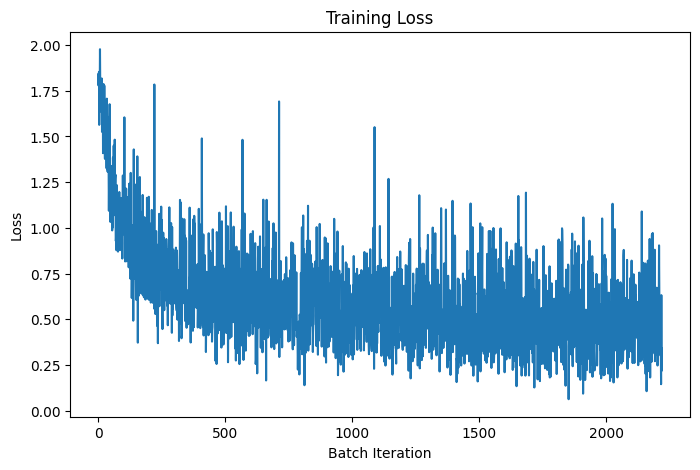

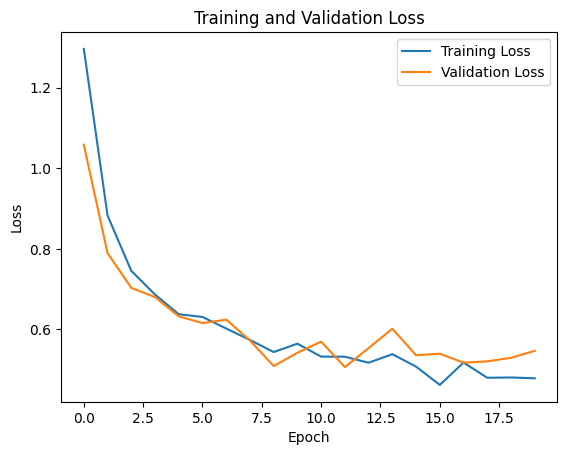

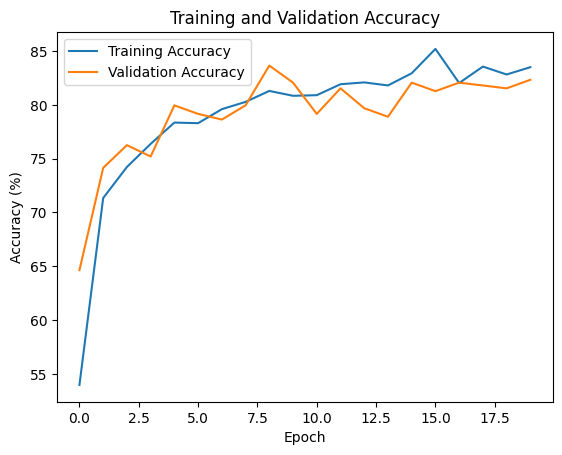

In [7]:
plt.figure(figsize=(8,5))
plt.plot(batch_losses)
plt.title("Training Loss")
plt.xlabel("Batch Iteration")
plt.ylabel("Loss")
plt.show()
# Plot training loss over time
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training accuracy over time
plt.figure()
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

In [8]:
model.eval()
y_true = []
y_pred = []
correct_test =0
with torch.no_grad():
  for i,data in enumerate(testloader):
      inputs, labels =  data
      inputs, labels = inputs.to(device), labels.to(device)
      outputs= model(inputs)
      _,predicted= torch.max(outputs.data,1)
      correct_test += (predicted == labels).sum()
      y_pred.extend(predicted.cpu().numpy())
      y_true.extend(labels.cpu().numpy())
  test_accuracy = 100 * correct_test.item() / len(testset)
  print("Test Accuracy:", test_accuracy)

Test Accuracy: 82.32189973614776


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



Precision: 0.8304
Recall: 0.8232
F1 Score: 0.8119


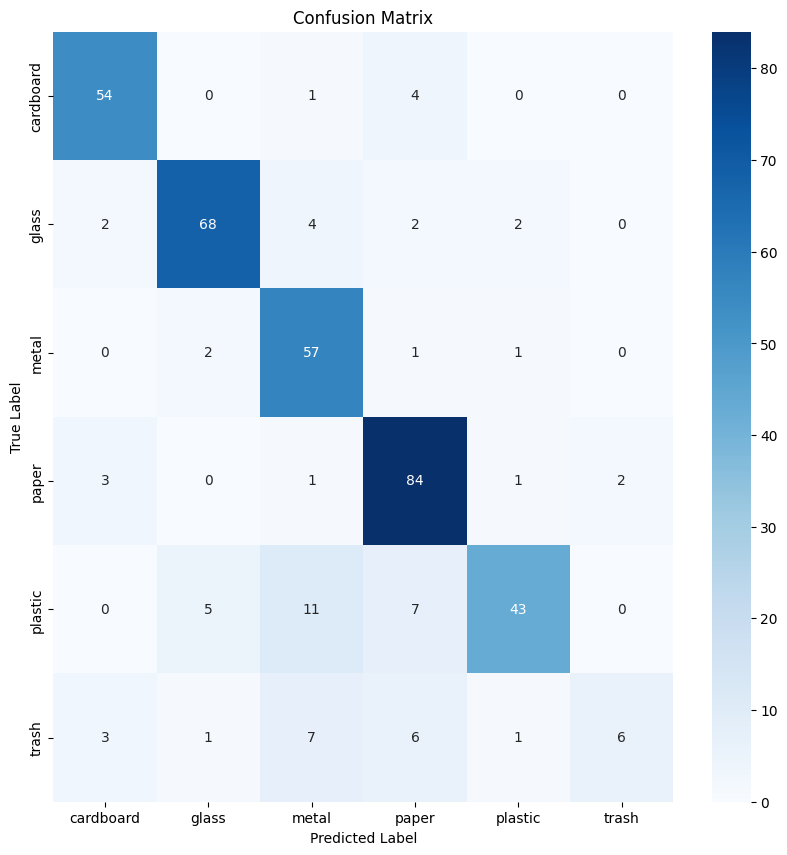

In [ ]:
class_names = dataset.classes
conf_matrix = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

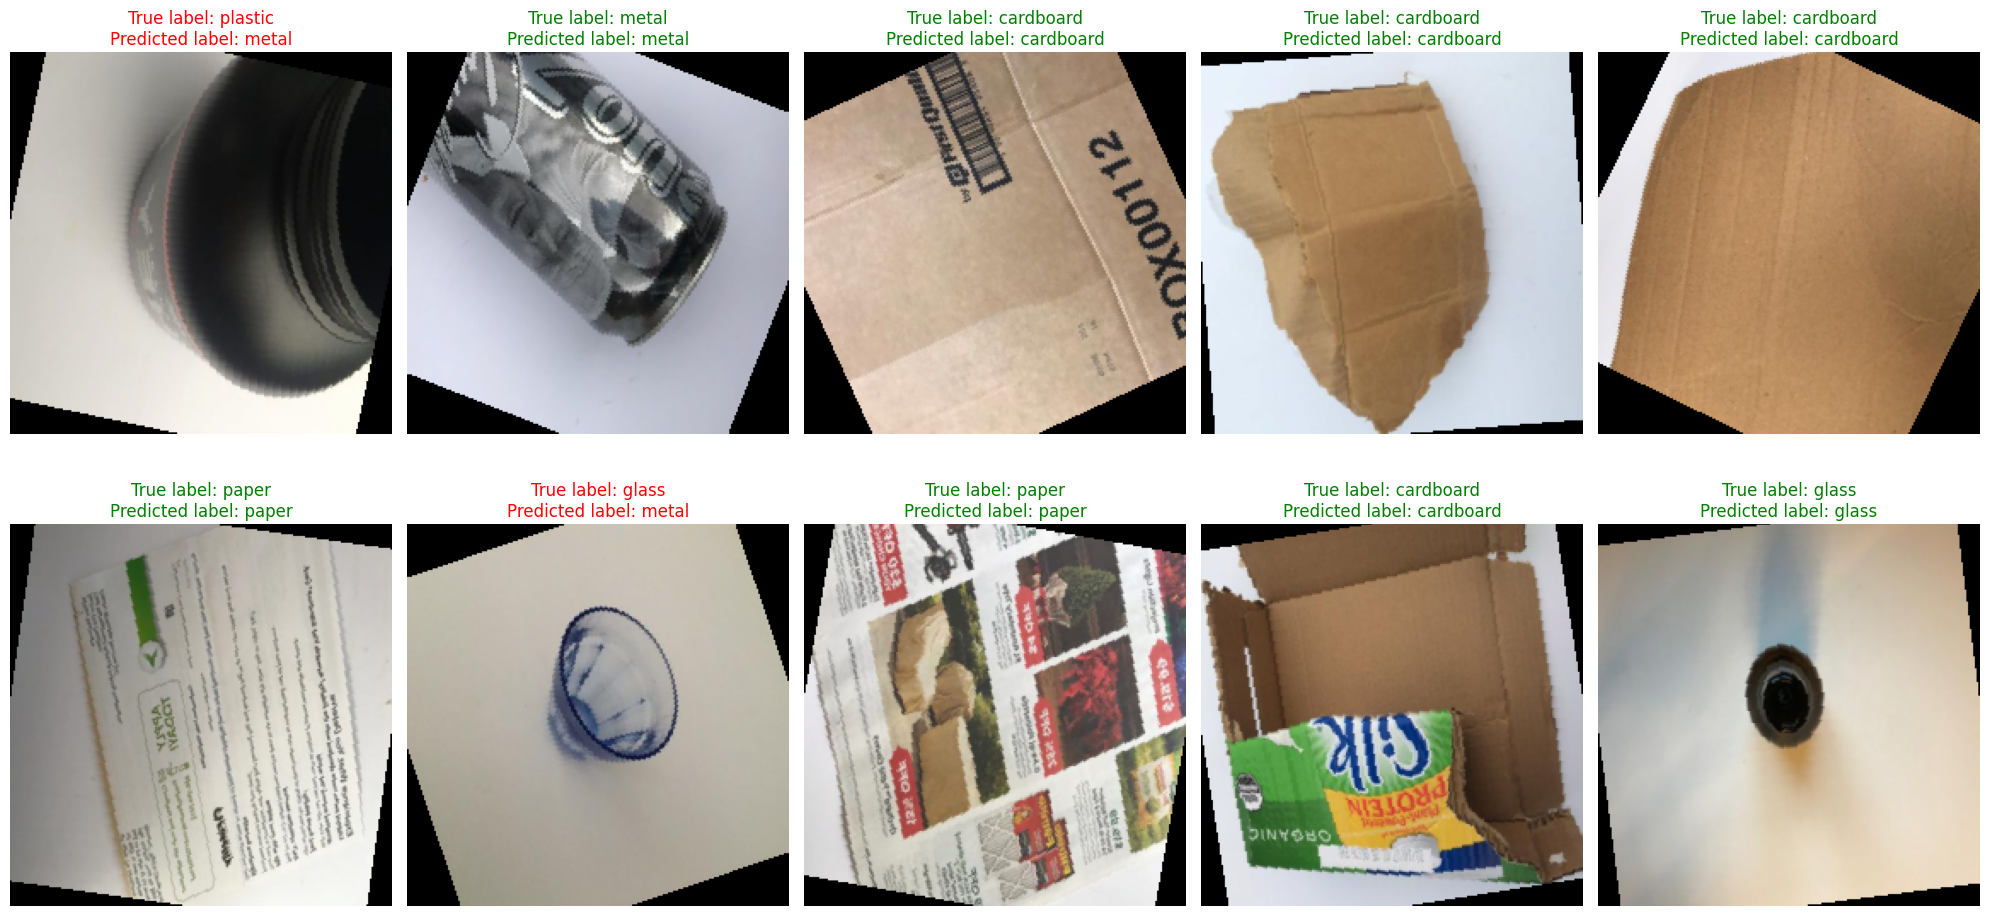

In [ ]:
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)
images = images.to(device)
class_names = dataset.classes
# get sample outputs
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Undo normalization for visualization (standard ResNet normalization)
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    # Color coding: Green if correct, Red if wrong
    color = 'green' if preds[i] == labels[i] else 'red'

    plt.title(f"True label: {class_names[labels[i]]}\nPredicted label: {class_names[preds[i]]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()